In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.time import Time, TimeDelta
import os
from itertools import combinations

from baseband_tasks.io import hdf5
from baseband_tasks.functions import Square
from baseband_tasks.dm import DispersionMeasure

import tools.tools as tools
import tools.correlation as correlation
import tools.decorrelation as decorrelation

# plt.style.use('~/Documents/mplstyles/paper.mplstyle')


In [3]:
DM = 56.7185
dm = DispersionMeasure(DM)
blur = 16

data_path = "../data/MPs/"
files = os.listdir(data_path)
# files = [f for f in files if f.endswith('.h5')]
files = [os.path.join(data_path, f) for f in files]

# define sn to be the number after "SN-" and before ".hdf5" in filename (files)
sns = np.zeros_like(files, dtype=float)
times = np.zeros_like(files, dtype=float)
for i, file in enumerate(files):
    sn_start = file.find('SN-') + len('SN-')
    sn_end = file.find('.hdf5')
    sn = float(file[sn_start:sn_end])
    sns[i] = sn
    time_start = file.find('MJD-') + len('MJD-')
    time_end = file.find('_SN')
    time = float(file[time_start:time_end])
    times[i] = time

fs = np.array([hdf5.open(f, 'r') for f in files])

great_ts = [60631.0849231004, 60631.095014371196, 60631.103663024645]
num_peaks_arr = np.array([4, 3, 3])

great_ts = np.array([60631.0849231004, 60631.09329920986, 60631.095014371196,
                     60631.10117956385, 60631.103663024645])
num_peaks_arr = np.array([4, 3, 3, 4, 3])

# great_ts_idx = [np.argmin(np.abs(times - t)) for t in great_ts]
# print(great_ts_idx)

# high_sns = np.where(sns > 20)[0]
# print(files)
# fs = fs[great_ts_idx]

f_combinations = list(combinations(range(len(fs)), 2))

sample_f = fs[0]
print(sample_f.sample_rate)
time_step = (1/sample_f.sample_rate).to(u.ms)
base_ts = np.linspace(0, sample_f.shape[0] * time_step, sample_f.shape[0]).to(u.ms)

2929687.500000003 Hz


In [4]:
blur = 16
blurs = [blur] * len(fs)
f_len = 1344 // blur

lin_results = np.zeros((len(f_combinations), f_len))
numpy_results = np.zeros((len(f_combinations), f_len))
weights = np.zeros(len(f_combinations))

lin_results_avg = np.zeros(len(f_combinations))
numpy_results_avg = np.zeros(len(f_combinations))
weights_avg = np.zeros(len(f_combinations))

dts = np.zeros(len(f_combinations)) * u.min

avg_spect = correlation.get_average_spectrum(fs, blurs)
# plt.plot(avg_spect[1], avg_spect[0])
# plt.show()


for i, (na, nb) in enumerate(f_combinations):
    # if i > 100:
    #     break
    dts[i] = TimeDelta(np.abs(times[nb] - times[na]), format='jd').to(u.min)
    lin_results[i], numpy_results[i], weights[i], freqs = decorrelation.correlate_two_MPs(fs[na], fs[nb], blur, blur, plot=False)
    # lin_results_avg[i], numpy_results_avg[i], weights_avg[i] = decorrelation.correlate_two_MPs(fs[na], fs[nb], blur, blur, plot=False, avg_spect=avg_spect)
    if i % 200 == 0:
        print(f"Processed {i}/{len(f_combinations)} combinations")

Processed 0/3741 combinations
Processed 200/3741 combinations
Processed 400/3741 combinations
Processed 600/3741 combinations
Processed 800/3741 combinations
Processed 1000/3741 combinations
Processed 1200/3741 combinations
Processed 1400/3741 combinations
Processed 1600/3741 combinations
Processed 1800/3741 combinations
Processed 2000/3741 combinations
Processed 2200/3741 combinations
Processed 2400/3741 combinations
Processed 2600/3741 combinations
Processed 2800/3741 combinations
Processed 3000/3741 combinations
Processed 3200/3741 combinations
Processed 3400/3741 combinations
Processed 3600/3741 combinations


In [1]:
min_dt = np.min(dts)
max_dt = np.max(dts)
dt_bins = np.linspace(min_dt.value, max_dt.value, 10) * u.min
dt_bin_centers = (dt_bins[:-1] + dt_bins[1:]) / 2

lin_results_binned = np.zeros((len(dt_bin_centers), f_len))
numpy_results_binned = np.zeros((len(dt_bin_centers), f_len))
norm_counts = np.zeros(len(dt_bin_centers))
print(min_dt, max_dt)
print(dt_bins)

# sort lin_results, numpy_results, and weights by dt bins
sorted_indices = np.argsort(dts)
dts_sorted = dts[sorted_indices]
lin_results_sorted = lin_results[sorted_indices]
numpy_results_sorted = numpy_results[sorted_indices]
weights_sorted = weights[sorted_indices]

for i, dt in enumerate(dts_sorted):
    try:
        bin_index = np.where(dt < dt_bins)[0][0] - 1
    except IndexError:
        bin_index = len(dt_bins) - 2

    lin_results_binned[bin_index, :] += lin_results_sorted[i] * weights_sorted[i]
    numpy_results_binned[bin_index, :] += numpy_results_sorted[i] * weights_sorted[i]
    norm_counts[bin_index] += 1

# normalize the binned results
lin_results_binned /= norm_counts[:, np.newaxis]
numpy_results_binned /= norm_counts[:, np.newaxis]
central_freq = freqs[len(freqs) // 2]
freqs_shifted = freqs - central_freq
print(freqs_shifted[0])

NameError: name 'np' is not defined

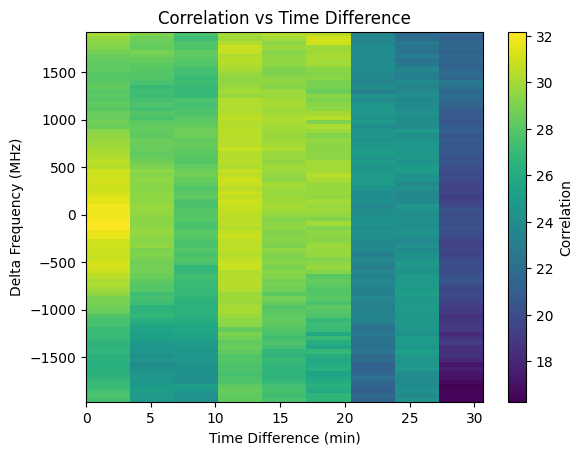

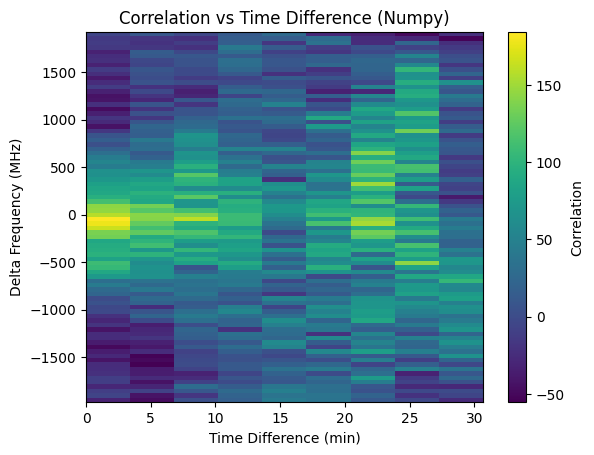

In [11]:
plt.imshow(lin_results_binned.T, aspect='auto', extent=[dt_bins[0].value, dt_bins[-1].value, freqs_shifted.value[0], freqs_shifted.value[-1]])
plt.colorbar(label='Correlation')
plt.xlabel('Time Difference (min)')
plt.ylabel('Delta Frequency (MHz)')
plt.title('Correlation vs Time Difference')
plt.show()

plt.imshow(numpy_results_binned.T, aspect='auto', extent=[dt_bins[0].value, dt_bins[-1].value, freqs_shifted.value[0], freqs_shifted.value[-1]])
plt.colorbar(label='Correlation')
plt.xlabel('Time Difference (min)')
plt.ylabel('Delta Frequency (MHz)')
plt.title('Correlation vs Time Difference (Numpy)')
plt.show()

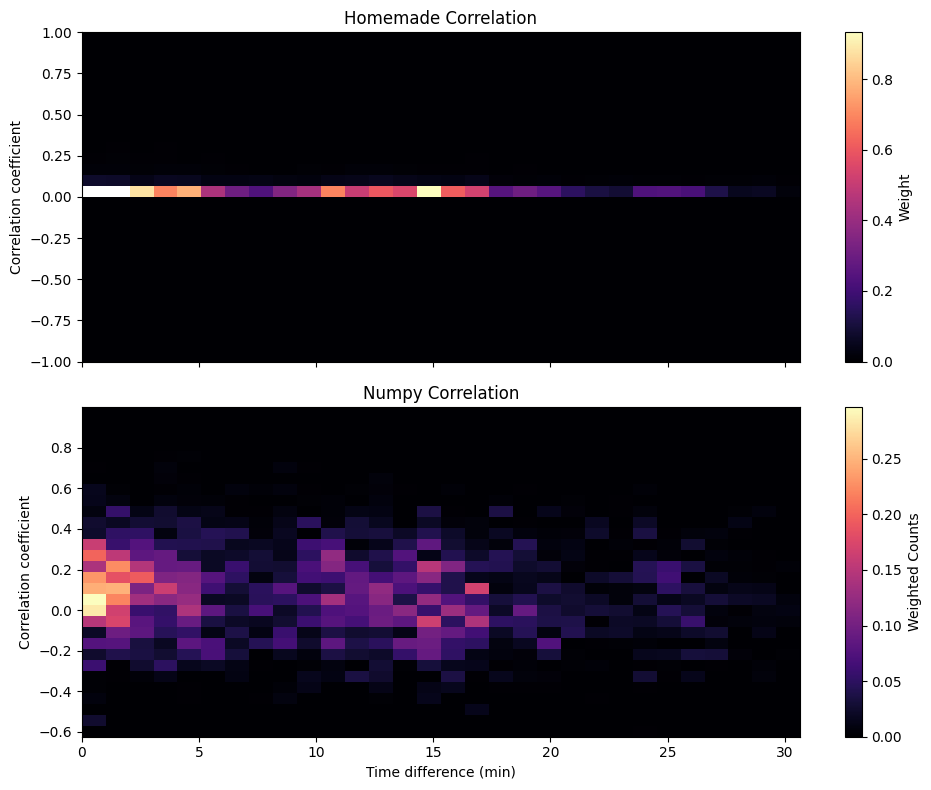

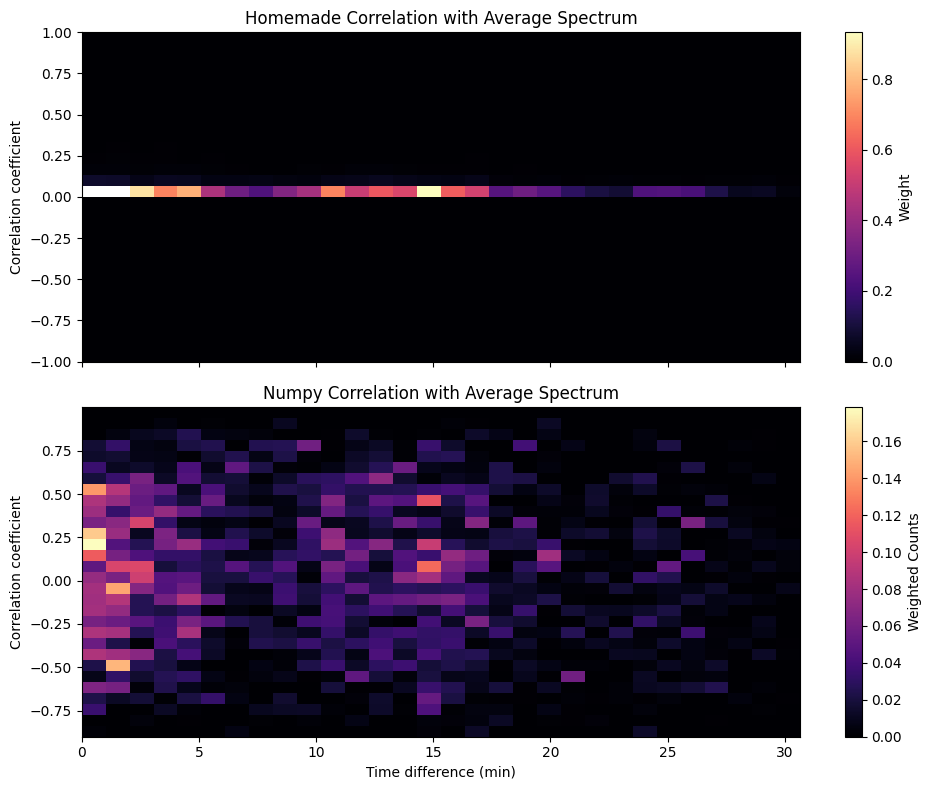

In [8]:
lim = 1
bins = [30, 30]
density = True
cmin = 0.
cmax = 1.
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

im1 = axs[0].hist2d(dts.to_value(u.min), lin_results, bins=bins, cmap='magma', weights=weights,
               range=[[np.min(dts.to_value(u.min)), np.max(dts.to_value(u.min))], [-lim, lim]],
               density=density, cmin=cmin, cmax=cmax)
axs[0].set_ylabel('Correlation coefficient')
axs[0].set_title('Homemade Correlation')
plt.colorbar(im1[3], ax=axs[0], label='Weight')
im2 = axs[1].hist2d(dts.to_value(u.min), numpy_results, bins=bins, cmap='magma', weights=weights,
                     density=density, cmin=cmin, cmax=cmax)
axs[1].set_ylabel('Correlation coefficient')
axs[1].set_title('Numpy Correlation')
axs[1].set(xlabel='Time difference (min)')

plt.colorbar(im2[3], ax=axs[1], label='Weighted Counts')
plt.tight_layout()
plt.show()

# fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# im1 = axs[0].hist2d(dts.to_value(u.min), lin_results_avg, bins=bins, cmap='magma', weights=weights_avg,
#                range=[[np.min(dts.to_value(u.min)), np.max(dts.to_value(u.min))], [-lim, lim]],
#                density=density, cmin=cmin, cmax=cmax)
# axs[0].set_ylabel('Correlation coefficient')
# axs[0].set_title('Homemade Correlation with Average Spectrum')
# plt.colorbar(im1[3], ax=axs[0], label='Weight')
# im2 = axs[1].hist2d(dts.to_value(u.min), numpy_results_avg, bins=bins, cmap='magma', weights=weights_avg,
#                      density=density, cmin=cmin, cmax=cmax)
# axs[1].set_ylabel('Correlation coefficient')
# axs[1].set_title('Numpy Correlation with Average Spectrum')
# axs[1].set(xlabel='Time difference (min)')
# plt.colorbar(im2[3], ax=axs[1], label='Weighted Counts')
# plt.tight_layout()
# plt.show()


# fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# axs[0].scatter(dts.to(u.min), lin_results, marker='o', label='Homemade', alpha=np.maximum(weights/np.max(weights), 0.2))
# axs[0].set_ylabel('Correlation coefficient')
# # axs[0].set_ylim(-1, 1)
# axs[0].legend() 

# axs[1].scatter(dts.to(u.min), numpy_results, marker='o', label='Numpy', alpha=np.maximum(weights/np.max(weights), 0.2))
# axs[1].set_ylabel('Correlation coefficient')
# axs[1].legend()
# axs[1].set(xlabel='Time difference (min)')
# plt.show()


# plt.plot(dts, lin_results, 'o', label='Homemade')
# plt.plot(dts, numpy_results, 'x', label='Numpy')
# plt.xlabel('Time difference (s)')
# plt.ylabel('Correlation coefficient')
# plt.legend()
# plt.show()

In [5]:
blurs = [64, 64, 16, 16, 32]
na = 2
nb = 4

dt = TimeDelta(great_ts[nb] - great_ts[na], format='jd')
print(dt.to(u.minute))

fa = fs[na]
fb = fs[nb]

res_homemade, res_numpy, weight = decorrelation.correlate_two_MPs(fa, fb, blurs[na], blurs[nb], plot=False)
print(f"Correlation coefficient: {res_homemade:.4f} (homemade), {res_numpy:.4f} (numpy)")

12.454060966847464 min
Correlation coefficient: 0.0238 (homemade), 0.1946 (numpy)


In [47]:
def sigma(lmbda, tau, dp, ds):
    return lmbda/ (2 * np.pi) * np.sqrt((dp - ds) / (const.c * tau) * dp / ds)

def tau_at_13(tau, nu):
    return tau * (nu / (13.75*u.GHz))**4

In [51]:
dp = 2 * u.kpc
d = -0.5 * u.pc
ds = dp + d

nu_16 = 1.66 * u.GHz
lambda_16 = (const.c / nu_16).to(u.m)
nu_13 = 13.75 * u.GHz
lambda_13 = (const.c / nu_13).to(u.m)
tau_16 = 1 * u.us
tau_13 = tau_at_13(tau_16, nu_16)
print(tau_13.to(u.ns))

0.21243279318735056 ns


In [45]:
sigma_16 = sigma(lambda_16, tau_16, dp, ds)
sigma_13 = sigma(lambda_13, tau_13, dp, ds)
print(f"Sigma at 1.6 GHz: {sigma_16.to(u.km)}")
print(f"Sigma at 13.75 GHz: {sigma_13.to(u.km)}")

Sigma at 1.6 GHz: 206.22293496393186 km
Sigma at 13.75 GHz: 1708.1719010566644 km


In [52]:
dp_ism = 2 * u.kpc
d_ism = -0.24 * u.kpc
ds_ism = dp_ism + d_ism

tau_13_ism = 0.04 * u.ns
lambda_13_ism = lambda_13

sigma_13_ism = sigma(lambda_13_ism, tau_13_ism, dp_ism, ds_ism)
print(f"Sigma at 13.75 GHz for ISM: {sigma_13_ism.to(u.km)}")

Sigma at 13.75 GHz for ISM: 91925.78488444028 km


In [55]:
(92000/120 * u.s).to(u.min)

<Quantity 12.77777778 min>